# Estrategia de Crecimiento para Bellabeat: Análisis de Patrones de Actividad

## 1. Introducción 
### 1.1. Contexto del Caso de Estudio

Este proyecto es un caso de estudio estratégico para [**Bellabeat**](https://bellabeat.com), una empresa de tecnología enfocada en la salud y el bienestar de las mujeres. Bellabeat busca expandir su base de clientes y optimizar su estrategia de marketing y desarrollo de productos (como Leaf, Time y Spring) mediante el análisis de los hábitos de sus usuarias.

Dado que Bellabeat opera con datos privados, este análisis utiliza el *dataset* público de **FitBit Fitness Tracker Data** como un **sustituto (proxy)** representativo para inferir los comportamientos y patrones que Bellabeat debe priorizar.


### 1.2. Preguntas Guía y Objetivos Estratégicos

El análisis está guiado por las siguientes preguntas clave de negocio, con el fin de informar las campañas de marketing y la experiencia del usuario de Bellabeat:

1.  **Comportamiento de Consistencia:** ¿Podemos segmentar a las usuarias basándonos en la **consistencia** de sus hábitos de salud?
2.  **Identificación de Oportunidades:** ¿Existen patrones de uso (ej., alta actividad vs. pocos pasos) que Bellabeat pueda abordar con mensajes específicos de **salud integral**?
3.  **Fidelización (Engagement):** ¿Qué tipo de usuarias son las más activas y cuáles son las más **inconsistentes**? ¿Qué tipo de mensajes de marketing podría crear Bellabeat para *reenganchar* a las usuarias que pierden el hábito?
5.  **Usuarios con Datos Incompletos:** ¿Qué proporción de usuarios proporciona datos incompletos o inconsistentes (lo que indica un bajo *engagement* con el dispositivo)?

### 1.3. Recursos de investigación de la Salud
Para contestar efectivamente a las preguntas, hay que establecer cuales son los rangos saludables respectivos según las investigaciones de organizaciones de la salud.

#### Actividad saludables según los pasos - Relationship of Daily Step Counts to All-Cause Mortality and Cardiovascular Events

https://www.jacc.org/doi/10.1016/j.jacc.2023.07.029

Meta-análisis para cuantificar las asociaciones dosis-respuesta de las métricas de recuento de pasos medidas objetivamente en la población general.

#### Directrices de la OMS sobre actividad física y comportamientos sedentarios

https://iris.who.int/items/65310979-92e8-4c98-8092-5a16ca07fc2f

Actividad recomendada entre 150 a 300 minutos de actividad moderada semanales para persona de 18 a 64 años. Para ello se usará un calculo de las Intensidades correspondientes(2 y 3) a la actividades descritas de manera díaria y semanal. 

---

## 2. Preparación y Limpieza de Datos 
### 2.1. Fuente de Datos (Dataset Proxy)
Para garantizar que el análisis estratégico se base en datos fiables, se aplicó un riguroso proceso de Extracción, Transformación y Carga (ETL) al conjunto de datos de FitBit:

* **Correcciones Técnicas:** Se resolvieron y validaron las inconsistencias técnicas más críticas, incluyendo:
    * **Estandarización de Unidades de Tiempo** (corrección de errores de conversión entre minutos, horas y días).
    * **Validación de METs** y re-categorización de los niveles de intensidad para garantizar una clasificación precisa de la actividad.

En caso de querer usar los datos directamente lo puede hacer por el dataset corregigo [FitBit Fitness Tracker Data: Corregido](https://www.kaggle.com/datasets/mvr513/fitbit-fitness-tracker-data-corrected)

Si quiere procesar y exportar los archivo del dataset orginal puede usar el repositorio [Fitbit-Data-Cleaning-ETL](https://github.com/MauricioVrx/Fitbit-Data-Cleaning-ETL), compatible con otros rangos de fechas si se disponen de los archivos.

Los registros originales corresponden a ***[FitBit Fitness Tracker Data](https://www.kaggle.com/datasets/arashnic/fitbit) (CC0: Public Domain, dataset made available through Mobius)***, que contiene registros personales de seguimiento de actividad física, frecuencia cardíaca y sueño por minuto. 

### 2.2 Formato de archivos y uso de datos
El sistema recopila y procesa los datos por medio de carpetas separadas por rangos de fechas que contendrán el conjunto de datos **'Intensidad', 'Calorias', 'Sueño', 'Pasos'** de las usuarias donde estarán en formatos **'Minutos', 'Horas', 'Días'**. Además de el archivo **METs** si se requiere confirmar la Intensidad y el archivo ***dailyActivity*** donde tendrán la actividad combinada diaria.
 

### 2.3 Comprensión de los datos
Se describirá en pocas a que corresponden los datos principales a utilizar, estos no son especificados en el dataset original. Al referirse a los tipos datos, estos corresponen a los archivos y a sus columnas respectivamente.

#### 2.3.1 Calorias 
Corresponde a la cantidad de **calorias quemadas** de manera sedentaria sumada a la de realizar alguna acción física. A lo largo de los formatos de los archivos solo se realiza una sumatoria de **Minutos -> Hora -> Días**.

#### 2.3.2. Pasos
Cantidad de **Pasos** detectados por el dispositivo. A lo largo de los formatos de los archivos solo se realiza una sumatoria de **Minutos -> Hora -> Días**.

#### 2.3.3 METs
**MET** significa **"equivalente metabólico de la tarea"** (*Metabolic Equivalent of Task*) y es una unidad de medida para estimar el gasto energético de una actividad física. Un MET representa la energía que una persona consume en reposo. Los valores METs del dataset original y del corregido se encuentran en formato entero donde se se multiplico el valor por diez, donde el MET 1(reposo) ahora es diez.  
Solo se dispondrá el formato CSV en minutos porque este es convertido en los archivos de **Intensidad**. No se usará en este análisis porque que se procesó y se comprobó en la limpieza anterior. 

#### 2.3.4 Intensidad 
Intensidad de actividad física realizada según el rango MET. Los límites se basan en los datos originales.

| Intensidad (Valor) | Rango METs Mínimo | Tipo Actividad |
| :--- | :--- | :--- |
| 0 | METs < 15 | **Sedentaria** / Reposo |
| 1 | 15 $\le$ METs < 35 | **Ligera** |
| 2 | 35 $\le$ METs < 60 | **Moderada** |
| 3 | METs $\ge$ 60 | **Intensa** |

El archivo en formato **Minutos** contiene el nivel de la Intensidad, en el archivo **Horas** no solo contiene la sumatoria de los valores, sino que contiene nuevas columnas, como el promedio y la sumatoria en minutos dependiendo del nivel de intensidad. Por último en el formato **Días** es igual a la anterior.



## 3. Importaciones y creación de variables clave

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
from datetime import datetime

# --- Directory and Path Configuration ---

# Base directory for the original data (lambda function for dynamic date range)
base_dir   = lambda date: f"./data/export_{date}"

# list of dir names
dates_list = ['3.12.16-4.11.16', '4.12.16-5.12.16']

# VARIABLES BASADA EN SALUD
# *** Metas Diarias Intensidad (Basado en OMS) ***
LI_INTENSITY_GOAL_VALUES = [0 , 22, 32, 43, np.inf]
LI_INTENSITY_GOAL_NAMES  = ['flag_sedentary', 'flag_meets_min_health', 'flag_meets_optimal_goal', 'flag_meets_best_goal']
LI_INTENSITY_NAMES_ESP   = ['sedentario', 'mínimo saludable', 'objetivo óptimo', 'objetivo máximo']

# *** Cantidad de pasos diarios (Aproximado según American College of Cardiology Foundation)***
LI_STEPS_GOAL_VALUES    = [0, 2735, 4930, 7126, 10000, np.inf]
LI_STEPS_ROWS_NAMES_ESP = ['Sedentario', 'Mínimo', 'leve', 'Óptimo', 'Muy Activo']



## 4. Funciones 

### 4.1. Funciones iniciales e integración de columnas

In [2]:
# Limit data range from dataframe
def limit_date_range(df, date_range, activity = 'ActivityDay'):
    """ From a DataFrame use data range from name directory

        Args:
            df (pd.DataFrame) : DataFrame with all info from users.
            date_range  (str) : Data range on string format (%m.%d.%y-%m.%d.%y).

        Returns:
            df_dailyActivity (pd.DataFrame) : Merged DataFrame with Daily info from all users.
    """
    sep_dates = date_range.split('-')
    initial_date = str(datetime.strptime(sep_dates[0], '%m.%d.%y').date())
    last_date    = str(datetime.strptime(sep_dates[1], '%m.%d.%y').date())

    range = df[(df[activity] >= initial_date) & (df[activity] <= last_date)]
    return range


# Merge dataframes de las fechas
def connect_dailyActivity_files(dates_list = dates_list, time_type = 'daily', info_type = 'Activity' , time_activity = 'ActivityDay'):
    """ Read and merges multiple csv dailys info from all users.
        Args:
            dates_list (list)   : name file - listado con de las direcciones donde se encuentran los archivos 
            time_type  (str)    : name file - type time name (minute, hourly, daily)
            info_type  (str)    : name file - type info name (Activity, Intensities, Calories, Steeps)
            time_activity (str) : Time column name from file

        Returns:
            df_dailyActivity (pd.DataFrame) : Merged DataFrame with Daily info from all users.
    """
    df_dailyActivity = pd.read_csv(f'{base_dir(dates_list[0])}/{time_type}{info_type}.csv')
    df_dailyActivity = limit_date_range(df_dailyActivity, dates_list[0], time_activity)
    for date in dates_list[1:]:
        df_con = pd.read_csv(f'{base_dir(date)}/{time_type}{info_type}.csv')
        df_con = limit_date_range(df_con, date, time_activity)
        df_dailyActivity = pd.merge(
                df_dailyActivity, 
                df_con, 
                how='outer'
            )
    
    df_dailyActivity[time_activity] = pd.to_datetime(df_dailyActivity[time_activity]) # Formato fecha
    return df_dailyActivity


def add_info_columns(df, df_minutes_merged, li_goal_names = LI_INTENSITY_GOAL_NAMES, li_goal_values = LI_INTENSITY_GOAL_VALUES):
    user_df = df.copy()

    #  Columna con el número de la semana según el estándar ISO 8601
    user_df['Week_ISO'] = user_df['ActivityDay'].dt.isocalendar().week

    # Dataframe con calorias quemadas en sedentario (mediana por usuario)
    cero_calories = df_minutes_merged[(df_minutes_merged['Intensity'] == 0) & (df_minutes_merged['Steps'] == 0)].groupby(['Id']).agg(
        sedentary_calories_per_minute = ('Calories', 'median'),
    )

    # Combinar dataframes
    user_df = pd.merge(
        user_df,
        cero_calories,
        on=['Id',],
        how='left'
    )

    # calorias quemadas diarias al estar sedentaio 
    user_df['calories_sedentary'] = round(user_df['sedentary_calories_per_minute'] * user_df['minutes_instances'] , 0)
    # Calorías consumidas por medio de la actividad (total - sedentario) 
    user_df['calories_activity']  = user_df['Calories'] - user_df['calories_sedentary']
    # Si el valor diario es negartivo, si deja como que la actividad es de 0
    user_df.loc[user_df['calories_activity'] < 0, 'calories_activity'] = 0
    # Cambio a formato entero
    user_df['calories_activity'] = user_df['calories_activity'].astype(int)

    # *** Cálculo del Puntaje Combinado (Activity Score) ***
    # The Pondered Score reflects the effective volume of exercise.
    # 1 minute Vigorosa (Int 3) = 2 minutes Moderada (Int 2)
    # Calculo basado en el ejercicio que deber realizar una persona de 18 a 64 de manera semanal 
    user_df['combined_activity_score'] = (user_df['VeryActiveMinutes'] * 2) + user_df['ModeratelyActiveMinutes']

    # *** Creación de Flags de Cumplimiento ***
    if (li_goal_values[-1] != np.inf) & (len(li_goal_names) == len(li_goal_values)):
        li_goal_values.append(np.inf)

    if len(li_goal_names)+1 == len(li_goal_values):
        for i in range(0, len(li_goal_names)):
            user_df[li_goal_names[i]] = np.where(
                ((user_df['combined_activity_score'] >= li_goal_values[i]) & (user_df['combined_activity_score'] < li_goal_values[i+1])), 
                1, # 1 if True
                0  # 0 if False
            )
    
    return user_df
    

### 4.2. Funciones de gestión de clientes semanales

In [3]:
def user_type_list(df):
    """
    dado un rango de un datafrme retorna una lista de ids de los usuario
    """
    # Obtener los datos del Dataframe y los transforma en ndarray, luego elimina dos niveles de listas
    np_users = np.hstack(np.hstack(df.values))
    # Elimina campos vacíos y lo transforma a una lista de valores entero 
    np_users = np_users[~np.isnan(np_users)].astype(np.int64).tolist()

    return np_users


def filter_type_user(df, user_id_list):
    """ Filtra un DataFrame según el listado de Ids de tipo de usuario
        Args:
            df (pd.DataFrame)   : DataFrame with all info from users
            user_id_list (list) : Id list from clients type
        
        Returns:
            (pd.DataFrame) : Filtered DataFrame by user type ids
    """
    return df[df['Id'].isin(user_id_list)].copy()


def weekly_fig(df, user_type, ax_x = 'Week_ISO', ax_y = 'sum_all_calories', y_label = 'Calorías Quemadas Totales', title = 'Calorías Quemadas Semanales por Usuario'):
    """ Crea un gráfico con la actividad semanal de los usuarios en una categoría 
        Args:
            original_df (pd.DataFrame) : DataFrame agrupado con datos semanales de los usuarios
            user_type (str) : Nombre tipo de usuario
            ax_x (str)      : Formato de semana 
            ax_y (str)      : Nombre de columna del DataFrame a trazar
            y_label (str)   : Título de eje X
            title (str)     : Título del diagrama
    """

    plt.figure(figsize=(10, 6)) 

    sns.lineplot(
        data=df,
        x = ax_x,          # Eje X: El número de la semana
        y = ax_y,          # Eje Y: La métrica que quieres trazar
        hue='Id',          # Clave para la agrupación: crea una línea de color por cada 'Id'
        legend=False,      # Ocultar la leyenda por defecto (ya que hay muchos IDs)
        palette='tab20',   # Elige una paleta de colores para diferenciar las líneas
        alpha=0.6          # Hacer las líneas ligeramente transparentes para ver superposición
    )

    # Mejorar el X-axis para que muestre cada semana correctamente
    plt.xticks(df[ax_x].unique())

    plt.title(f'Usuarios {user_type} - {title}', fontsize=14)
    plt.xlabel('Semana ISO', fontsize=12)
    plt.ylabel(y_label, fontsize=12)

    sns.lineplot(
        data = df,
        x = ax_x,
        y = ax_y,
        color='black',
        linewidth=2.5,
        linestyle='--',
        errorbar=None, # No mostrar el error
        label='Promedio General'
    )
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


def weekly_info(user_weekly_activity, weeks_wellness_fulfilled, user_id_list, user_type_name ,show_info_figs = True, ret = True):
    """ Entrega un listado de usuarios y la cantidad de semanas que han podido lograr 
        Args:
            user_weekly_activity (pd.DataFrame) : DataFrame con los datos a nivel semanal de los usuarios
            user_id_list (list)  : Lista de Ids de usuario por tipo de cliente
            user_type_name (str) : Nombre tipo de usuario en español
            show_info_figs (Boolean) : Para condicional si se muestran los datos en pantalla
            ret (Boolean) : Para condicional si se retorna los DataFrames procesados

        Returns:
            weeky_info_df, weeks_wellness_df (pd.DataFrame) : Filtered DataFrame by user type ids
    """ 
    weeky_info_df     = filter_type_user(user_weekly_activity, user_id_list)
    weeks_wellness_df = filter_type_user(weeks_wellness_fulfilled, user_id_list)

    if show_info_figs == True:
        print(f"*** USUARIOS {user_type_name.upper()} ***")
        print(f' - Cantidad de usuarios       : {len(weeks_wellness_df)}')
        print(f' - Promedio intensidad        : %{round(weeks_wellness_df["mean_healty_activity"].mean(),2)}') 
        print(f' - Promedio cantidad de pasos : %{round(weeks_wellness_df["mean_healty_steps"].mean(),2)}') 

        weekly_fig(weeky_info_df, user_type_name)
        weekly_fig(weeky_info_df, user_type_name , ax_y = 'mean_steps', title = 'Promedio de pasos semanales por usuario', y_label = 'Promedio de pasos')
        weekly_fig(weeky_info_df, user_type_name , ax_y = 'combined_activity_score', title = 'Actividad semanales por usuario', y_label = 'Actividad según intensidad')

    if ret == True:
        return weeky_info_df, weeks_wellness_df

---

## 5. Correlación inicial: Intensidad, Pasos y Gasto Calórico

El siguiente análisis examina la relación entre las métricas de **Intensidad de la Actividad (en minutos)**, **Pasos diarios** y **Gasto Calórico**, utilizando el coeficiente de correlación de Pearson.

| | **Intensidad** | **Calorías** | **Pasos** |
| :--- | :--- | :--- | :--- |
| **Intensidad** | 1.0 | **0.911** | 0.852 |
| **Calorías** | **0.911** | 1.0 | 0.833 |
| **Pasos** | 0.852 | 0.833 | 1.0 |

Los resultados muestran una **correlación positiva, fuerte y muy significativa** entre las tres métricas clave, lo que valida la coherencia de los datos registrados por los dispositivos.

* **Intensidad y Calorías (r = 0.911):** Esta es la correlación más fuerte. Esto implica que el **tiempo dedicado a actividades de intensidad moderada o vigorosa** es el principal motor del gasto calórico. A mayor intensidad, mayor quema de calorías de forma muy predecible.
* **Intensidad y Pasos (r = 0.852):** Existe una fuerte relación entre la intensidad y la cantidad de pasos. Un aumento en la intensidad se traduce en un incremento considerable en el volumen de pasos.
* **Calorías y Pasos (r = 0.833):** La cantidad de pasos es un excelente predictor del gasto calórico del usuario, como es esperado.


In [4]:
# Obtener información em formato minutos de: Intensidad, Calorias, Pasos.
minutes_intensities = connect_dailyActivity_files(dates_list, time_type = 'minute', info_type = 'Intensities' , time_activity = 'ActivityMinute')
minutes_calories    = connect_dailyActivity_files(dates_list, time_type = 'minute', info_type = 'Calories'    , time_activity = 'ActivityMinute')
minutes_steps       = connect_dailyActivity_files(dates_list, time_type = 'minute', info_type = 'Steps'       , time_activity = 'ActivityMinute')

# Combinar Dataframes de cormatos minutos 
df_minutes_merged = pd.merge(
        minutes_intensities,
        minutes_calories,
        on=['Id', 'ActivityMinute'],
        how='left'
    )
df_minutes_merged = pd.merge(
        df_minutes_merged,
        minutes_steps,
        on=['Id', 'ActivityMinute'],
        how='left'
    )

# Correlaciones
df_minutes_merged[['Intensity' , 'Calories' , 'Steps' ]].corr()


,Intensity,Calories,Steps
Intensity,1.000000,0.911222,0.852119
Calories,0.911222,1.000000,0.832869
Steps,0.852119,0.832869,1.000000


### 6. Análisis en base de datos diarios 

#### 6.1. Creación de DataFrames de usuarios
Se recopila la información de todos los clientes a través de los rangos de fechas disponible almacenadas en la carpeta 'data/' con el formato '*export_[date1-date2]*'. 

In [5]:
# Creación de DataFrame con los datos diarios combinados 
merged_dailyActivity = connect_dailyActivity_files()

# Rango de fechas del dataframe combinado 
first_day       = merged_dailyActivity['ActivityDay'].min()
last_day        = merged_dailyActivity['ActivityDay'].max()
diff_days_range = (last_day - first_day).days + 1 

print("*** Datos rango de datos de las fechas ***\n")

print(f'Primera instancia : {first_day}')
print(f'Última instancia  : {last_day}\n')

print(f'Cantidad de días    : {diff_days_range}')
print(f'Cantidad de horas   : {diff_days_range * 24}')
print(f'Cantidad de minutos : {diff_days_range * 1440}')

*** Datos rango de datos de las fechas ***

Primera instancia : 2016-03-12 00:00:00
Última instancia  : 2016-05-12 00:00:00

Cantidad de días    : 62
Cantidad de horas   : 1488
Cantidad de minutos : 89280


### 6.2 Filtrado de usuarios con un mínimo cantidad de días registrados e integración de columnas claves

Se realizará el análsis a los usuario que dispongan de un mínimo de **56 días** registrados para el reconocimiento de comportamiento de clientes. 

Despues del filtrado se añaden las columnas necesarias para las futuras agrupaciones, tales como: calorías consumidas por actividad, número de semana, columnas en base del cumplimiento de Intensidad.

In [ ]:
# Contar cantidad de días registraod por usuario
count_user_days = merged_dailyActivity.groupby(['Id']).agg(
    count_records = ('ActivityDay', 'count')
)

# Filtar por cantidad mínima de 56 días (8 semanas)
count_inactive_user_days = count_user_days[(count_user_days['count_records'] > 35) & (count_user_days['count_records'] <= 56)]
count_user_days          = count_user_days[count_user_days['count_records'] > 56] 

# Filtrar registros diarios de los clientes con menor actividad para el analisis de usauarios inactivos
merged_less_dailyActivity = merged_dailyActivity[merged_dailyActivity['Id'].isin(count_inactive_user_days.index.to_list())]

# Filtrar registros diarios a partir de listado filtrado de usuarios 
merged_dailyActivity = merged_dailyActivity[merged_dailyActivity['Id'].isin(count_user_days.index.to_list())]

# Añadir la columnas nuevas
merged_less_dailyActivity = add_info_columns(merged_less_dailyActivity, df_minutes_merged)
merged_dailyActivity      = add_info_columns(merged_dailyActivity, df_minutes_merged)


### 6.3 Agrupar los registros diarios por el ID de los usuarios

In [17]:
user_activity = merged_dailyActivity.groupby(['Id',]).agg(
    # Primer y ultima fecha disponible del usuario
    initial_date = ('ActivityDay', 'min'),         # Find the earliest available date
    lastest_date = ('ActivityDay', 'max'),         # Find the lastest available date

    # Días con datos registrados
    count_records = ('ActivityDay', 'count'), 
    no_records    = ('ActivityDay', lambda x : diff_days_range - x.count()),

    # Días que tienen todos sus datos registrados (1440 minutos)
    full_days       = ('minutes_instances', lambda x: (x == 1440).sum()), # Tiene todos los datos de los días
    incomplete_days = ('minutes_instances', lambda x: (x != 1440).sum()), # Tiene menos de la cantidad diaria de minutos
    
    # *** Sección Calorías ***
    sum_all_calories      = ('Calories', 'sum'),
    sum_activity_calories = ('calories_activity', 'sum'),
    average_calories      = ('Calories', 'mean'),
    median_calories       = ('Calories', 'median'),

    # *** Sección Pasos ***
    median_steps    = ('Steps', 'median'),
    q1_steps      = ('Steps', lambda x: x.quantile(0.25)),  # Cuartil 1 (25%)
    q3_steps      = ('Steps', lambda x: x.quantile(0.75)),  # Cuartil 3 (75%)

    # # Categorías según la cantidad de pasos a lo largo del día 
    # mov_sedentary   = ('Steps', lambda x: ((x >= LI_STEPS_GOAL_VALUES[0]) & (x < LI_STEPS_GOAL_VALUES[1])).sum()),
    # mov_min         = ('Steps', lambda x: ((x >= LI_STEPS_GOAL_VALUES[1]) & (x < LI_STEPS_GOAL_VALUES[2])).sum()),
    # mov_light       = ('Steps', lambda x: ((x >= LI_STEPS_GOAL_VALUES[2]) & (x < LI_STEPS_GOAL_VALUES[3])).sum()),
    # mov_optimal     = ('Steps', lambda x: ((x >= LI_STEPS_GOAL_VALUES[3]) & (x < LI_STEPS_GOAL_VALUES[4])).sum()),
    # mov_very_active = ('Steps', lambda x: ((x >= LI_STEPS_GOAL_VALUES[4]) & (x < LI_STEPS_GOAL_VALUES[5])).sum()),


    # *** Sección Intensidad ***
    intensities_median         = ('combined_activity_score', 'median'),
    
    # Puntos de actividad
    combined_activity_score    = ('combined_activity_score', 'sum'),

    # Días con actividad física y suficiente
    flag_sedentary           = ('flag_sedentary'          , 'sum'),
    flag_meets_min_health    = ('flag_meets_min_health'   , 'sum'),
    flag_meets_optimal_goal  = ('flag_meets_optimal_goal' , 'sum'),
    flag_meets_best_goal     = ('flag_meets_best_goal'    , 'sum'),
    

    # *** Sección Sueño ***
    # Días que tienen registrado su actividad de sueño y si estos son de  sueño saludable ( mínimo 7 horas)
    days_of_sleep  = ('TotalMinutesAsleep', lambda x: (x > 0).sum()),
    healthy_sleep  = ('TotalMinutesAsleep', lambda x: (x > 420).sum()),
)

#### 6.4. Información de los archivos y sueño

#### 6.4.1. Días con registros vs. faltantes


Este Diagrama valida que se tiene los datos necesarios para realizar el análisis en el rango de fecha según los archivos, dentro de los **1586** días disponibles de los **26** usuarios, los cuales son faltan el **%1.6** (**26** registros).


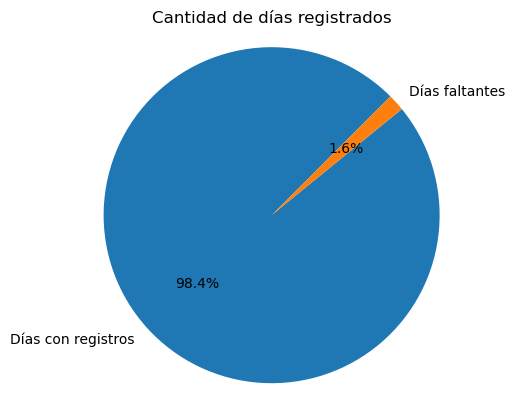

In [ ]:
plt.title('Cantidad de días registrados')
plt.pie(user_activity[['count_records', 'no_records']].sum() , 
        labels=['Días con registros', 'Días faltantes'], 
        autopct='%1.1f%%', 
        startangle=45
        )
plt.axis('equal')
plt.show()

#### 6.4.2. Registros de sueño
El dataset dispone de datos con registros de noches pero estos no han sido registrados por los sensores, 
si disponemos mejores registros de detección de sueño, hay un posible propuesta de marketing

In [ ]:
# Cantidad de dias en el dataset
print('Cantidad de días disponibles')
print(user_activity['count_records'].sum())

# Cantidad dias que tienen registro de sueño 
print('\nCantdad de dias con sueño registrados')
print(user_activity['days_of_sleep'].sum())

print('\nPorcentage de sueño registrados')
print(f"%{round(((user_activity['days_of_sleep'].sum()*100)/user_activity['count_records'].sum()), 2)}")



Cantidad de días disponibles
1586

Cantdad de dias con sueño registrados
796

Porcentage de sueño registrados
%50.19


### 6.5. Correlaciones de datos diarios de clientes

### 6.5.1. Calorías con Intensidad y cantidad de Pasos

En ambos casos la correlación entre la cantidad de calorias frente a los parametros saludables de Intesidad y Pasos se encuentra a nivel negativo con poca o nula actividad, mientras que esta llega a una correlación fuerte cuando se encuentyra en los parametros saludables.

#### Calorías con Intensidad
Correlación frente a la formula referente a la salud según la intencidad - **Combined_Activity_Score** : **0.76**  

**Calorías frente la cantidad de minutos según el nivel de intensidad saludable dentro de la semana**

| **Intensidades** |  **Flag_Sedentary** | **Flag_Meets_Min_Health** |**Flag_Meets_Optimal_Goal** |**Flag_Meets_Best_Goal** |
| :--- | :--- | :--- | :--- | :--- | 
| **Calorías** | -0.48 | -0.12 | -0.09 | 0.53 | 


**Calorías frente la cantidad de minutos minutos según el nivel de intensidad**

| **Intensidades** | **SedentaryMinutes** | **LightActiveMinutes** | **ModeratelyActiveMinutes** | **VeryActiveMinutes** | 
| :--- | :--- | :--- | :--- | :--- | 
| **Calorías** |  -0.36 |  0.23 | 0.56 | 0.69 | 


#### Calorías con Pasos
Correlación de la calorías frente a la cantidad de pasos - **Steps** : **0.61**  

**Pasos según el nivel de intensidad**

| Intensidades |**SedentaryMinutes** | **LightActiveMinutes** | **ModeratelyActiveMinutes** | **VeryActiveMinutes** |
| :--- | :--- |  :--- |  :--- |  :--- | 
|  Steps |  -0.62 | 0.48 |  0.70 |  0.72 | 


In [ ]:
merged_dailyActivity[['Calories', 'minutes_instances', 'Steps' ,'SedentaryMinutes', 'LightActiveMinutes', 'ModeratelyActiveMinutes', 'VeryActiveMinutes', 'combined_activity_score', 'flag_sedentary', 'flag_meets_min_health', 'flag_meets_optimal_goal', 'flag_meets_best_goal']].corr()

,Calories,minutes_instances,Steps,SedentaryMinutes,LightActiveMinutes,ModeratelyActiveMinutes,VeryActiveMinutes,combined_activity_score,flag_sedentary,flag_meets_min_health,flag_meets_optimal_goal,flag_meets_best_goal
Calories,1.000000,0.213744,0.614003,-0.361811,0.230470,0.568038,0.691517,0.761428,-0.484374,-0.120581,-0.090481,0.535275
minutes_instances,0.213744,1.000000,0.108469,0.512189,0.127454,0.086941,0.057421,0.081598,-0.085998,0.030325,-0.022964,0.073145
Steps,0.614003,0.108469,1.000000,-0.624914,0.476965,0.701818,0.726788,0.848676,-0.645934,-0.170748,-0.118082,0.717457
SedentaryMinutes,-0.361811,0.512189,-0.624914,1.000000,-0.651334,-0.622587,-0.366286,-0.551917,0.577059,0.105486,0.025989,-0.582326
LightActiveMinutes,0.230470,0.127454,0.476965,-0.651334,1.000000,0.426419,0.029812,0.218482,-0.574294,0.017920,0.061258,0.480807
ModeratelyActiveMinutes,0.568038,0.086941,0.701818,-0.622587,0.426419,1.000000,0.398737,0.749667,-0.589010,-0.169728,-0.123663,0.668226
VeryActiveMinutes,0.691517,0.057421,0.726788,-0.366286,0.029812,0.398737,1.000000,0.905848,-0.404627,-0.162756,-0.140941,0.506629
combined_activity_score,0.761428,0.081598,0.848676,-0.551917,0.218482,0.749667,0.905848,1.000000,-0.564076,-0.195855,-0.158834,0.674279
flag_sedentary,-0.484374,-0.085998,-0.645934,0.577059,-0.574294,-0.589010,-0.404627,-0.564076,1.000000,-0.138052,-0.127897,-0.775985
flag_meets_min_health,-0.120581,0.030325,-0.170748,0.105486,0.017920,-0.169728,-0.162756,-0.195855,-0.138052,1.000000,-0.055079,-0.334178


### 6.5.2. Prueba Visual: Diagrama de Dispersión (Volumen vs. Intensidad)

El Diagrama de Dispersión valida visualmente la **fuerte correlación positiva** ($\mathbf{r > 0.88}$) entre el **Volumen de Pasos** y el **Puntaje de Intensidad Combinada** (Minutos Efectivos). Cada punto representa un día de actividad registrado.

#### Hallazgos Clave:

* **Validación de la Tendencia:** La nube de puntos sigue una clara **trayectoria ascendente**, confirmando que los Pasos son el principal factor que impulsa la intensidad efectiva.
* **Concentración en el Riesgo:** La alta densidad de puntos cerca del origen ($\text{Pasos} < 5,000$) valida la existencia del **Segmento de Riesgo Crónico** y los días de baja actividad.
* **Aumento de la Variabilidad:** La **dispersión (ensanchamiento)** de los puntos en los rangos más altos de Pasos (sobre los $15,000$) indica que la eficiencia de la actividad varía significativamente entre los usuarios.
    * *Implicación:* Algunos usuarios son más eficientes (alta intensidad con menos pasos), mientras que otros requieren un volumen de pasos mucho mayor para lograr la misma intensidad. Esto refuerza la necesidad de analizar la **calidad (Intensidad)** sobre solo la **cantidad (Pasos)**.

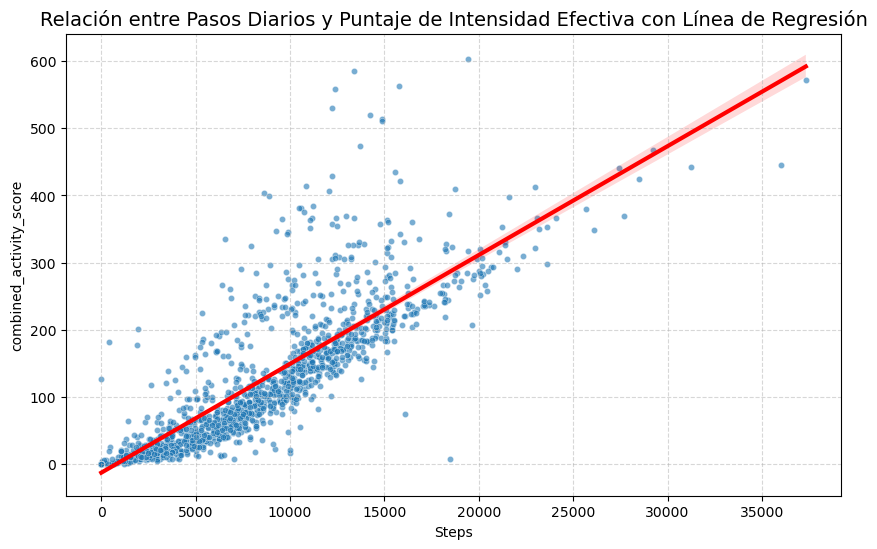

In [ ]:
plt.figure(figsize=(10, 6))
# 1. Crear el diagrama de dispersión de base (como ya lo hiciste)
sns.scatterplot(
    x='Steps',                       
    y='combined_activity_score',      
    data=merged_dailyActivity,
    alpha=0.6,
    s=20
)

# 2. AÑADIR LA LÍNEA DE REGRESIÓN
# sns.regplot calcula y dibuja la línea que mejor se ajusta a los datos (mínimos cuadrados)
sns.regplot(
    x='Steps',                       
    y='combined_activity_score',      
    data=merged_dailyActivity,
    scatter=False, # Importante: No dibujar los puntos de nuevo
    color='red',   # Color de la línea de ajuste
    line_kws={'lw': 3} # Ancho de la línea
)

plt.title('Relación entre Pasos Diarios y Puntaje de Intensidad Efectiva con Línea de Regresión', fontsize=14)
# ... [otras etiquetas y leyendas] ...
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---
## 7. Categorizar usuarios activos

### 7.1. Categoría usuarios con dependiendo de la cantidad de pasos frente a la intensidad
Segmentos Clave Identificados (Conteo de Usuarios)

La segmentación cruzada del comportamiento de Pasos e Intensidad dio como resultado los siguientes grupos de usuarios:

| Categoría de Pasos Típicos | Intensidad Típica (Moda) | Conteo de Usuarios | Implicación del Comportamiento |
| :--- | :--- | :--- | :--- |
| **Sedentario/Mínimo** | **Riesgo Crónico** ($< 22 \text{ min}$) | **6 Usuarios** | Inactividad sistémica (fallan el mínimo de salud). |
| **Óptimo/Muy Activo** | **Máximo Rendimiento** ($\ge 43 \text{ min}$) | **15 Usuarios** | Alto compromiso y rendimiento sostenido. |


In [19]:
###### Usuarios catalogados por las medianas de pasos frente a intensidad

user_activity['healthy_steps'] = pd.cut(
    user_activity['median_steps'],    # Columna a clasificar
    bins   = LI_STEPS_GOAL_VALUES,    # Los límites definidos
    labels = LI_STEPS_ROWS_NAMES_ESP, # Las etiquetas definidas
    right  = False                    # El límite izquierdo es inclusivo ([0, 5000))
)

user_activity['intensities'] = pd.cut(
    user_activity['intensities_median'], # Columna a clasificar
    bins   = LI_INTENSITY_GOAL_VALUES,   # Los límites definidos
    labels = LI_INTENSITY_NAMES_ESP,     # Las etiquetas definidas
    right  = False                       # El límite izquierdo es inclusivo ([0, 5000))
)

df_segmentation_count = pd.crosstab(
    # La columna que quieres en las filas
    user_activity['healthy_steps'], 
    # La columna que quieres en las columnas
    user_activity['intensities'],
)

df_segmentation_count


intensities,sedentario,mínimo saludable,objetivo óptimo,objetivo máximo
healthy_steps,,,,
Sedentario,3,0,1,0
Mínimo,3,2,0,0
leve,0,0,0,2
Óptimo,0,0,0,8
Muy Activo,0,0,0,7


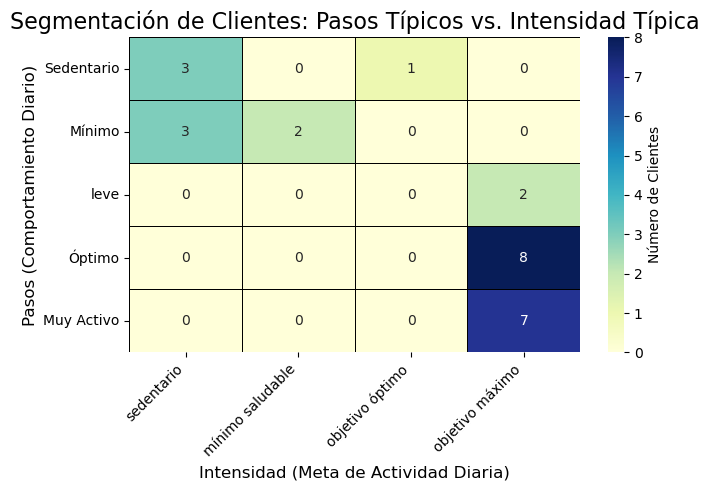

In [ ]:
column_order = LI_INTENSITY_NAMES_ESP

row_order = LI_STEPS_ROWS_NAMES_ESP

# Reindexar el DataFrame para asegurar el orden visual deseado
df_plot_heatmap = df_segmentation_count.reindex(index=row_order, columns=column_order)


# Crear el Mapa de Calor
plt.figure(figsize=(7, 5)) # Ajusta el tamaño según sea necesario

sns.heatmap(
    df_plot_heatmap,
    annot=True,        # Mostrar los números dentro de las celdas
    fmt="g",           # Formato general para los números (sin decimales para conteo)
    cmap="YlGnBu",     # Mapa de color (Yellow-Green-Blue, o elige otro como "Reds", "Greens")
    linewidths=.5,     # Líneas entre las celdas
    linecolor='black', # Color de las líneas
    cbar_kws={'label': 'Número de Clientes'} # Etiqueta para la barra de color
)

# Añadir etiquetas y título
plt.title('Segmentación de Clientes: Pasos Típicos vs. Intensidad Típica', fontsize=16)
plt.xlabel('Intensidad (Meta de Actividad Diaria)', fontsize=12)
plt.ylabel('Pasos (Comportamiento Diario)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0) # Para que las etiquetas de las filas no estén rotadas
plt.tight_layout()
plt.show()

###  7.2. Riesgo vs Rendimiento

* Mediana de días en Riesgo (36.0): El cliente cuyo comportamiento típico es sedentario pasa la mediana de $\mathbf{36}$ días (de un total de $\approx 62$ días) sin alcanzar el umbral mínimo de salud.

* Mediana de días en Alto Rendimiento (61.0): El cliente cuyo comportamiento típico es dar muchos pasos tiene la mediana de $\mathbf{61}$ días donde logra el máximo esfuerzo.


Se detectó un segmento minoritario donde la **intensidad es alta a pesar de un volumen de pasos bajo**. Este es el **Cliente Eficiente**.

* **Significado:** La intensidad alta sin un alto volumen de Pasos sugiere actividad de **bajo impacto** (ciclismo, pesas, etc.). Esta discrepancia es crucial la campaña de marketing, ya que la métrica de Pasos subestima su esfuerzo real.






In [ ]:
intensities_columns =  LI_INTENSITY_GOAL_NAMES
df_median_steps_intensities = user_activity.groupby('healthy_steps', observed=True).agg(
    {col: 'median' for col in intensities_columns}
)
df_median_steps_intensities.columns = LI_INTENSITY_NAMES_ESP
df_median_steps_intensities

,sedentario,mínimo saludable,objetivo óptimo,objetivo máximo
healthy_steps,,,,
Sedentario,36.0,6.0,2.5,14.0
Mínimo,30.0,8.0,6.0,19.0
leve,15.5,3.0,6.5,37.0
Óptimo,4.5,1.5,3.0,51.0
Muy Activo,1.0,0.0,0.0,61.0


### 7.3. Cuantificación del Impacto: Volumen Total de Días por Segmento

El siguiente análisis utiliza la **Suma del Total de Días** para cada categoría de cumplimiento de intensidad, lo que permite cuantificar dónde se concentra la **inactividad (Riesgo)** y el **máximo esfuerzo (Rendimiento)** en nuestra muestra.

La tabla cruza la **Clasificación Típica de Pasos** (filas) con la **Suma Total de Días** que los clientes de ese segmento tuvieron en cada nivel de Intensidad.

| Pasos Típicos | Días de Riesgo (< 22 min) | Días de Mínimo (22-31 min) | Días de Óptimo (32-42 min) | Días de Élite (> 43 min) |
| :--- | :--- | :--- | :--- | :--- |
| **Sedentario** | **143** | 25 | 10 | 67 |
| **Mínimo** | **151** | 40 | 27 | 88 |
| **Leve** | 31 | 6 | 13 | 74 |
| **Óptimo** | 38 | 17 | 26 | **404** |
| **Muy Activo** | 22 | 1 | 1 | **402** |

### 7.3.1. Cuantificación del Riesgo Crónico (Inactividad)

El mayor volumen de inactividad se concentra en los segmentos de pasos más bajos:

* **Alto Volumen de Inactividad:** Los clientes Sedentarios y Mínimos (Pasos Típicos Bajos) generaron un total de **$\mathbf{294 \text{ días}}$** ($143 + 151$) sin alcanzar siquiera el umbral mínimo de salud.
    > *Este hallazgo cuantifica el problema principal para Bellabeat: la inactividad crónica. Se confirma que el **riesgo de salud** se debe principalmente al **bajo volumen de pasos***.

### 7.3.2. Cuantificación del Rendimiento 

La mayor parte del tiempo de ejercicio de alta calidad proviene del segmento activo:

* **Concentración de la Élite:** Los clientes Óptimos y Muy Activos (Pasos Típicos Altos) generaron un total de **$\mathbf{806 \text{ días}}$** ($404 + 402$) en la categoría de Máximo Rendimiento (`Días de Élite`).
* **Implicación:** Esto demuestra que el volumen de la **actividad de alta intensidad** es producido, casi en su totalidad, por el grupo que ya tiene un alto volumen de pasos, validando la correlación observada.

### 7.3.3. El Cliente Eficiente (Volumen Mínimo, Impacto Fuerte)

Aunque la inactividad de élite se concentra en los segmentos activos, es crucial notar el bajo volumen de días de riesgo en esos segmentos:

* Los clientes **Muy Activos** produjeron solo **$\mathbf{22 \text{ días}}$** de riesgo de inactividad, en comparación con los $\mathbf{143 \text{ días}}$ de los Sedentarios. Esto demuestra que su volumen de inactividad es marginal, reforzando la fiabilidad de este segmento.

### 7.3.4. El Cliente Fuerte (Menor Movimiento, Mayor Intensidad)

Los en esta sección están enfocadas mayormente a quienes realizar ejercicio de fortalecimiento muscular, donde la capacidad de movimiento es mucho más limitado pero más intenso.


In [ ]:
df_sum_steps_intensities = user_activity.groupby('healthy_steps', observed=True).agg(
    {col: 'sum' for col in intensities_columns}
)
df_sum_steps_intensities.columns = LI_INTENSITY_NAMES_ESP
df_sum_steps_intensities

,sedentario,mínimo saludable,objetivo óptimo,objetivo máximo
healthy_steps,,,,
Sedentario,143,25,10,67
Mínimo,151,40,27,88
leve,31,6,13,74
Óptimo,38,17,26,404
Muy Activo,22,1,1,402


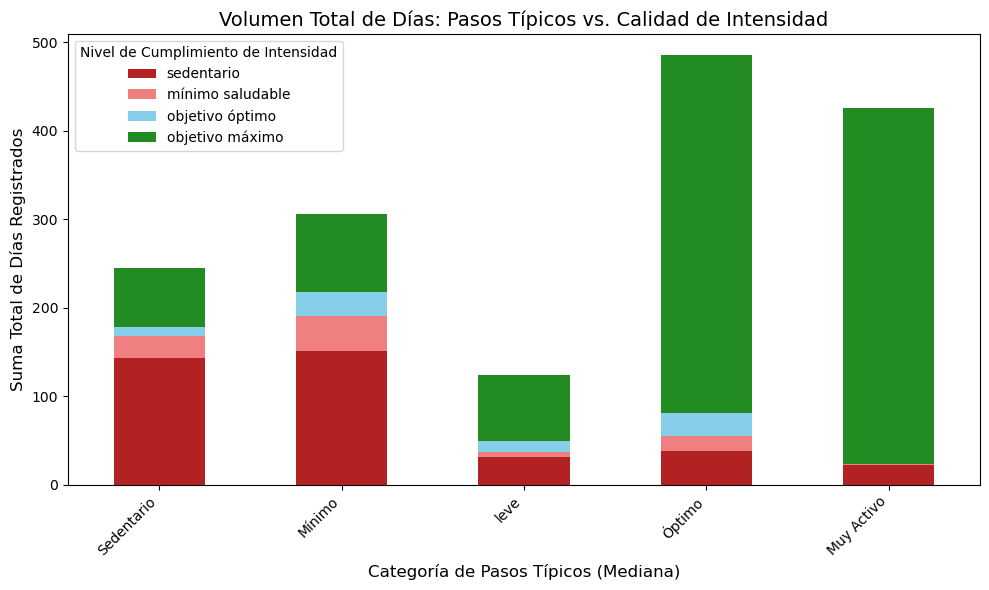

In [ ]:
# 1. Definir el orden y colores de las categorías de Intensidad 
intensity_order = LI_INTENSITY_NAMES_ESP

colors = ['firebrick', 'lightcoral', 'skyblue', 'forestgreen']
color_map = dict(zip(intensity_order, ['firebrick', 'lightcoral', 'skyblue', 'forestgreen']))

# 2. Reordenar las columnas del DataFrame para que se apilen correctamente
df_plot = df_sum_steps_intensities.reindex(columns=intensity_order)

# 3. Crear el gráfico de barras apiladas
df_plot.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10, 6), 
    color=[color_map[col] for col in intensity_order]
)

# 4. Añadir etiquetas y título
plt.title('Volumen Total de Días: Pasos Típicos vs. Calidad de Intensidad', fontsize=14)
plt.xlabel('Categoría de Pasos Típicos (Mediana)', fontsize=12)
plt.ylabel('Suma Total de Días Registrados', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Nivel de Cumplimiento de Intensidad', loc='upper left')
plt.tight_layout()
plt.show()

---

## 8. Analizar tipos usuarios por actividad semanal

Se busca encontrar el comportamiento de los tipos de usuarios, se han dividido en cuatro categoría dependiendo de su actividad junto a su intensidad, desde los más sedentarios a las personas con mayor actividad. Estos han sido agrupados por el gráfico 'Segmentación de Clientes: Pasos Típicos vs. Intensidad Típica'.

**Pasos**  
* **Mínimo**('Sedentario', 'Mínimo', 'leve') 
* **Activo**('Óptimo', 'Muy Activo')

**Intensidades** 
* **Mínimo**('sedentario', 'mínimo saludable') 
* **Óptimo**('objetivo óptimo', 'objetivo máximo')

<br>

| Pasos / Intensidad| Mínimo | Óptimo |
| :--- | :--- | :--- | 
| **Mínimo** | 8 | 3 |
| **Activo** | 0 | 15 | 

<br>

### 8.1 Tipos de usuarios

**- Usuario Sedentario(sedentary)**: Son los clientes que realiza poco o nada de actividad física, y pude que sean clientes que quieren monitorisar sus signos vitales o quieren mejorar sus hábitos de salud. Son **8** clientes que se encuentran en esta categoría con un **%30.8** del total.

**- Ususario Viajero(traveller)**: Son los usuarios que tienen una cantidad de pasos óptimos saludables o altos, pero su nivel de exigencia corporal es baja. En el listado actual de usuarios no hay una persona que se encuentre en esta categoría.

**- Usuario Fuerte(stronger)**: Usuarios que tienen una cantidad baja de pasos registrados pero con un alto nivel de exigencia. Pueden ser personas que predomine la exigencia de fuerza más que la de movimiento. Solo son **3** usuarios que calzan en esta categoría con un **%11.5** del total.

**- Usuario Saludable(Healthy)**: Son aquellos usuarios que tienen una actividad saludable en Intensidad y cantidad de Pasos. Son **15** clientes que se encuentran en esta categoría con un **%57.7** del total.



In [ ]:
# Agrupar por las dos columnas categóricas
df_segmentation_ids = user_activity.groupby(['healthy_steps', 'intensities'], observed=True).agg(
    lista_ids=('healthy_steps', lambda x: x.index.to_list()),  
).reset_index()

# Reestructurar la tabla para que se vea como un cuadrante
df_cuadrantes_ids = df_segmentation_ids.pivot(
    index='healthy_steps', 
    columns='intensities', 
    values='lista_ids'
)

# Slice por tipo de usuario
sedentary = user_type_list(df_cuadrantes_ids.iloc[:3,:2]) # Sedentario
traveller = user_type_list(df_cuadrantes_ids.iloc[3:,:2]) # Muchos Pasos / Poca Intensidad
stronger  = user_type_list(df_cuadrantes_ids.iloc[:3,2:]) # Pocos Pasos  / Alta Intensidad
healthy   = user_type_list(df_cuadrantes_ids.iloc[3:,2:]) # Muchos Pasos / Alta Intensidad


### 8.2. Gestionar DataFrames 

#### 8.2.1. Agrupar los usuarios con actividad semanal

In [ ]:
user_weekly_activity = merged_dailyActivity.groupby(['Id','Week_ISO']).agg(
    # Primer y ultima fecha disponible del usuario
    initial_date = ('ActivityDay', 'min'),  # Find the earliest available date
    lastest_date = ('ActivityDay', 'max'),  # Find the lastest available date

    # Días con datos registrados
    count_records = ('ActivityDay', 'count'), 

    # *** Sección Calorías ***
    sum_all_calories      = ('Calories', 'sum'),
    sum_activity_calories = ('calories_activity', 'sum'),
    median_calories       = ('Calories', 'median'),

    # *** Sección Pasos ***
    mean_steps  = ('Steps', 'mean'),
    sum_steps   = ('Steps', 'sum'),

    # *** Sección Intensidad ***
    intensities_median      = ('combined_activity_score', 'median'),
    
    # *** Puntos de actividad ***
    combined_activity_score = ('combined_activity_score', 'sum'),
)

# Quitar la primera y última semana ya que no se dispone de los datos de la semana entera
user_weekly_activity = user_weekly_activity[(user_weekly_activity.index.get_level_values('Week_ISO') > 10) & (user_weekly_activity.index.get_level_values('Week_ISO') < 19)]

# Ver si el usuario cumple con la intensidad y cantidad de pasos mínimos saludable en la semana
user_weekly_activity['healty_weekly_activity'] = user_weekly_activity['combined_activity_score'] >= LI_INTENSITY_GOAL_VALUES[-2]*7
user_weekly_activity['healty_weekly_steps']    = user_weekly_activity['sum_steps']               >= LI_STEPS_GOAL_VALUES[-3]*7

# Filtro para usar solo las semanas con todos los días de la semana
user_weekly_activity = user_weekly_activity[user_weekly_activity['count_records'] == 7]

user_weekly_activity = user_weekly_activity.reset_index()

#### 8.2.2. Agrupar infromación por cumplimiento 

In [ ]:
weeks_wellness_fulfilled = user_weekly_activity.groupby(['Id']).agg(
    count_weeks          = ('Week_ISO', 'count'),               # Contar la cantidad de semanas del usuario
    sum_healty_activity  = ('healty_weekly_activity', 'sum'),   # Cantidad de semanas con actividad saludable
    mean_healty_activity = ('healty_weekly_activity', 'mean'),  # Porcentaje total de cumplimiento de actividad   
    sum_healty_steps     = ('healty_weekly_steps', 'sum'),      # Cantidad de semanas con la cantidad de pasos saludable
    mean_healty_steps    = ('healty_weekly_steps', 'mean'),     # Porcentaje total de cumplimiento de la cantidad de pasos   
)

weeks_wellness_fulfilled = weeks_wellness_fulfilled.reset_index()

# Conversión a porcentaje 
weeks_wellness_fulfilled['mean_healty_activity'] = (weeks_wellness_fulfilled['mean_healty_activity'] * 100).round(2)
weeks_wellness_fulfilled['mean_healty_steps']    = (weeks_wellness_fulfilled['mean_healty_steps'] * 100).round(2)

### 8.3. Diagrama semanales

#### 8.3.1 Cumplimientos de comportamiento saludable de los usuarios 

La actividad varía según el tipo de usuarios. El usuario 'Sedentario' apenas cumplen con la actividad minima de pasos, pero cumplen un **%26.04** de actividad física, aunque este es irregular. No hay usuarios 'Viajeros' en los usuarios actuales. La cantidad de usuarios 'Fuertes' no son suficientes para tener un patron de comportamiento común. En Cambio los ususarios 'Saludables' son los que tienen un cumplimiento bastante elevado comportamiento más estables con **%84.36** en la cantidad de pasos, y un **%97.22** de al actividad según la intensidad.

| **Tipo Usuario** |  **Sedentario** | **Viajero** |**Fuerte** |**Saludable** |
| :--- | :--- | :--- | :--- | :--- | 
| **Cantidad usuarios** | 8 | 0 | 3 | 15 | 
| **Cumplimiento Intensidad** | % 26.04 | % 0 | % 79.17 | % 97.22 | 
| **Cumplimiento Pasos** | % 6.77 | % 0 | % 37.5 | % 84.36 | 

*** USUARIOS SEDENTARIOS ***
 - Cantidad de usuarios       : 8
 - Promedio intensidad        : %26.04
 - Promedio cantidad de pasos : %6.77


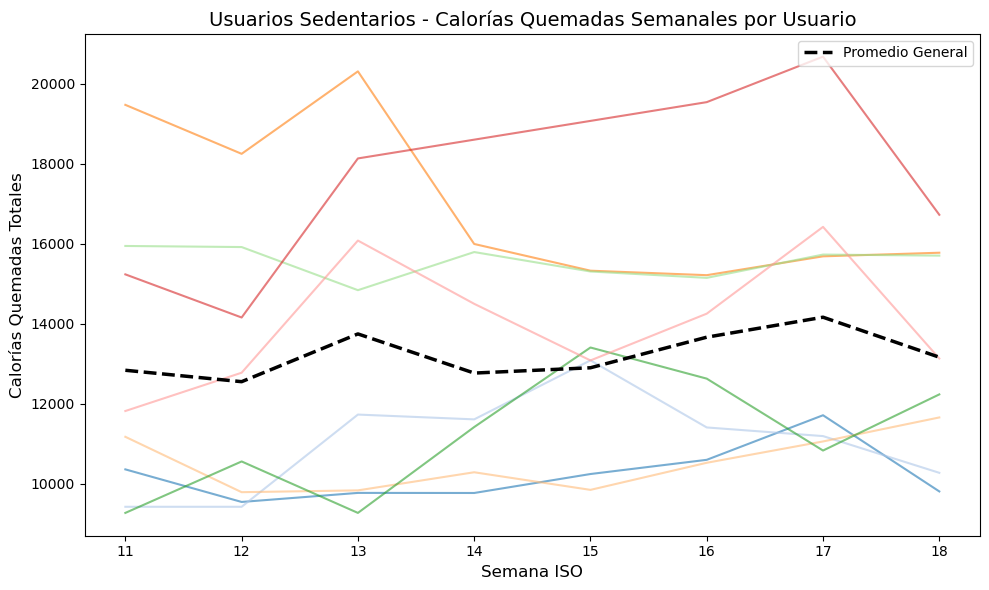

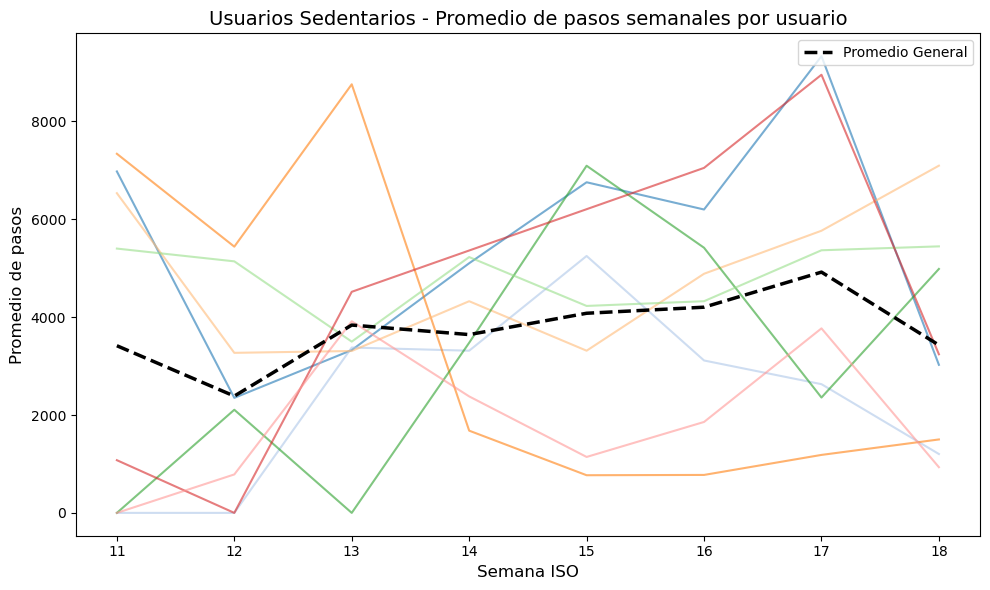

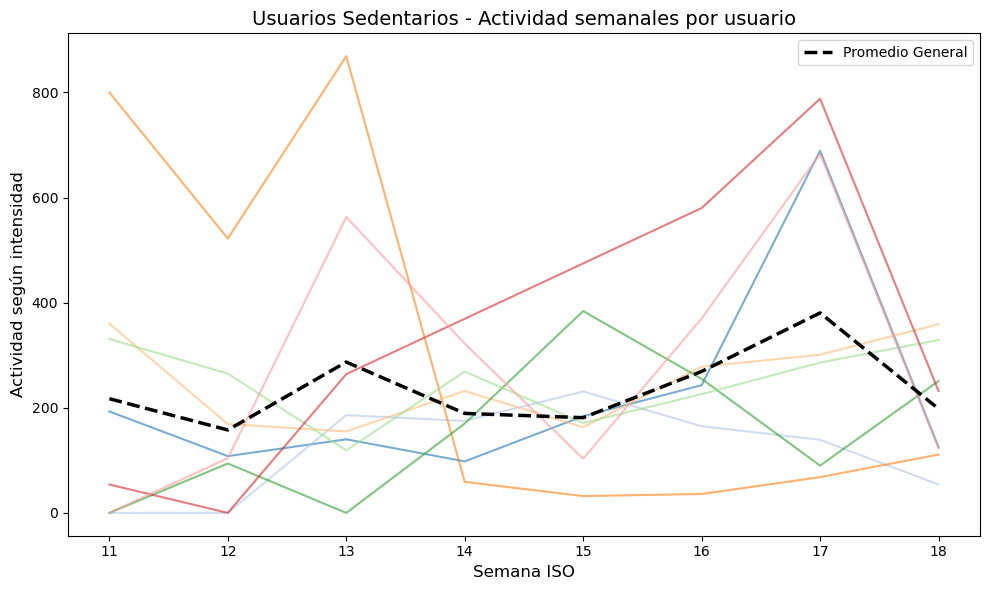

In [ ]:
weekly_info(user_weekly_activity, weeks_wellness_fulfilled, sedentary, 'Sedentarios', ret = False)

*** USUARIOS FUERTES ***
 - Cantidad de usuarios       : 3
 - Promedio intensidad        : %79.17
 - Promedio cantidad de pasos : %37.5


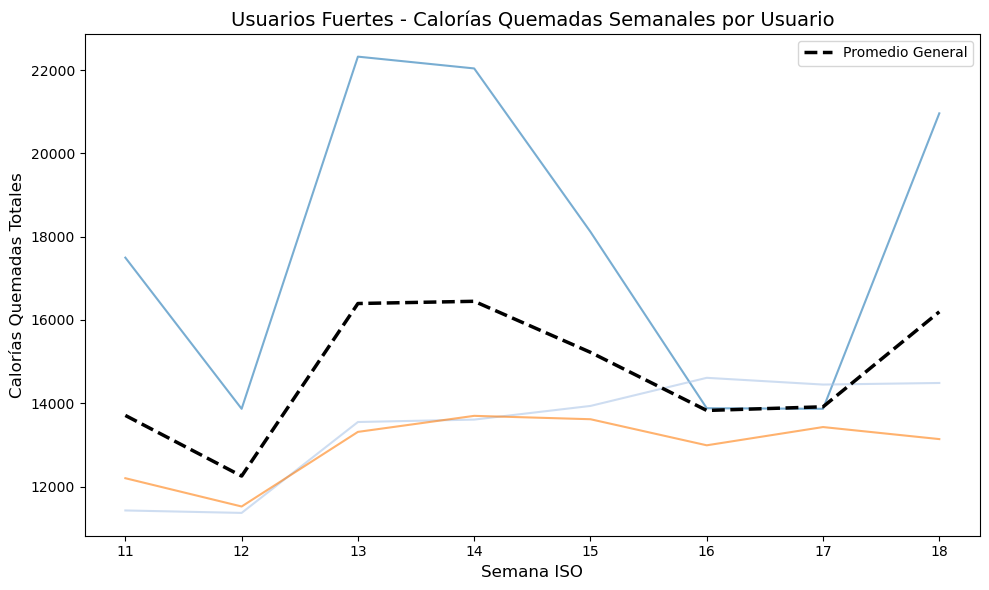

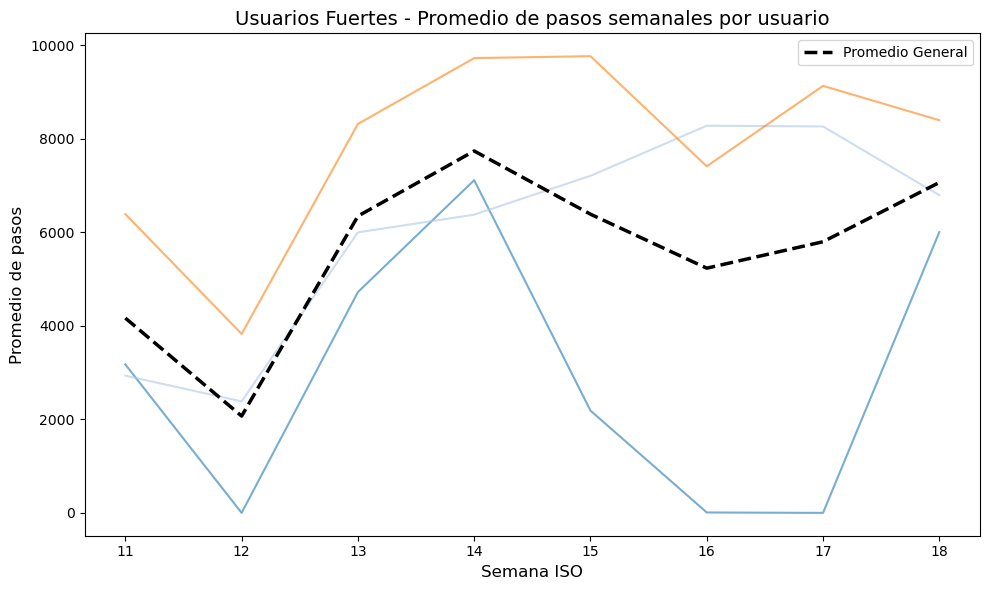

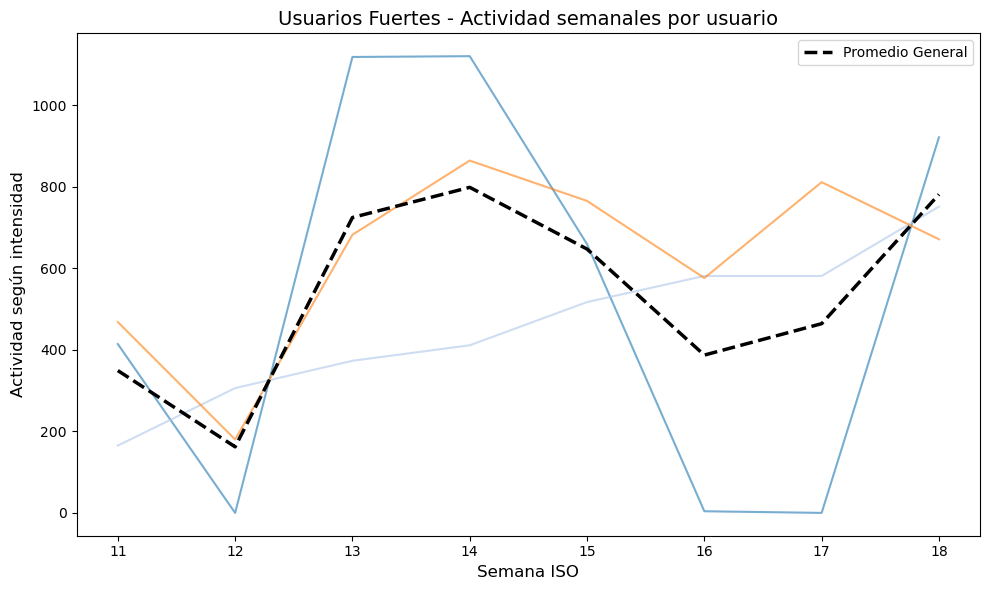

In [ ]:
weekly_info(user_weekly_activity, weeks_wellness_fulfilled, stronger, 'Fuertes', ret = False)

*** USUARIOS SALUDABLE ***
 - Cantidad de usuarios       : 15
 - Promedio intensidad        : %97.22
 - Promedio cantidad de pasos : %84.36


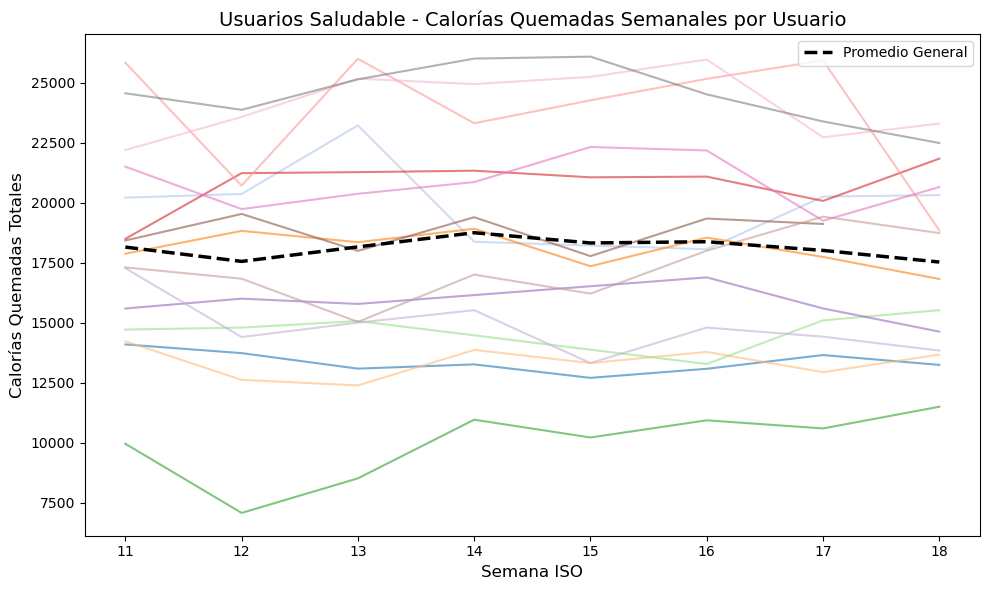

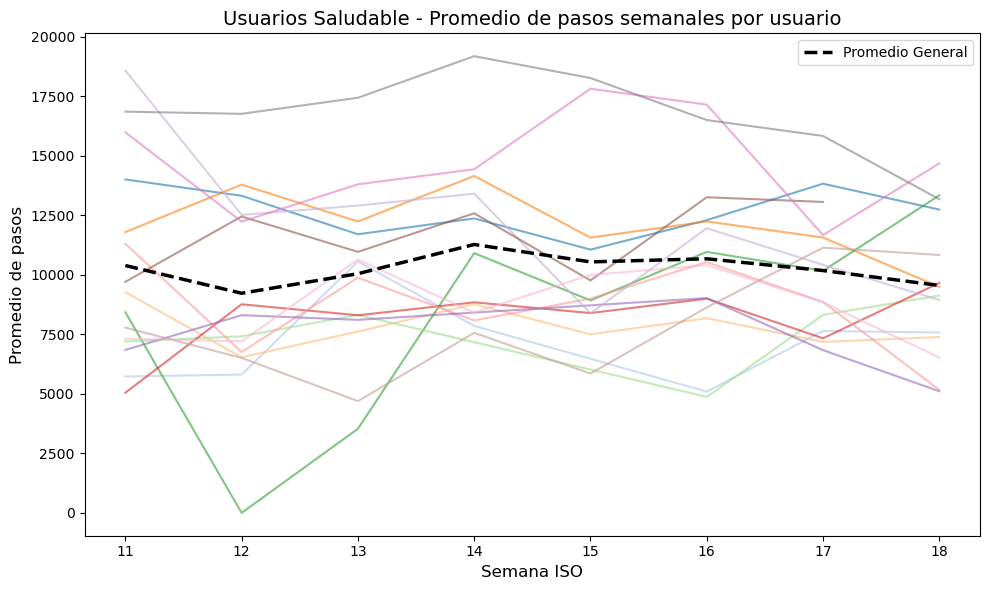

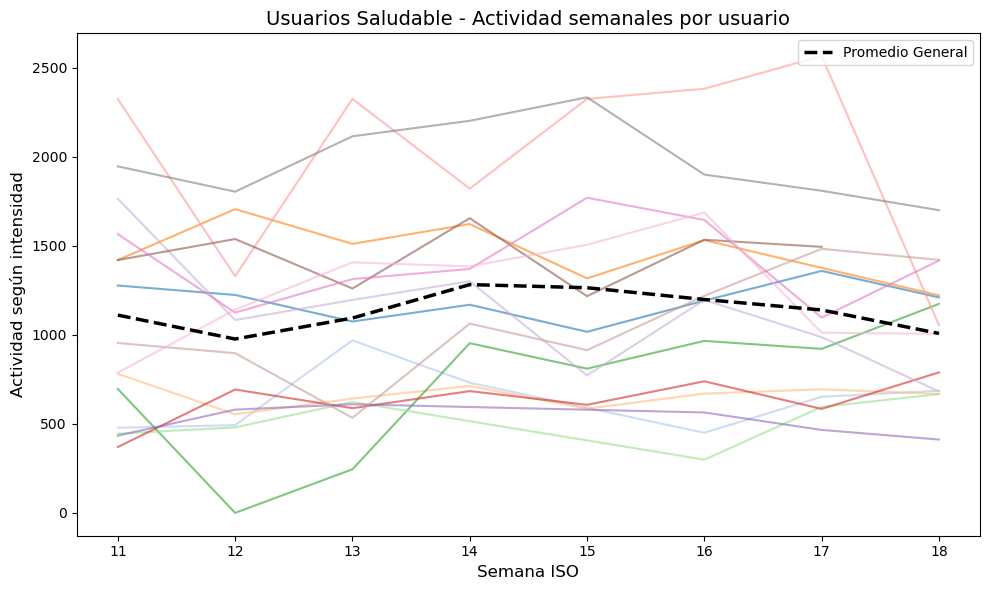

In [ ]:
weekly_info(user_weekly_activity, weeks_wellness_fulfilled, healthy, 'Saludable', ret = False)

---

## 9. Analizar usuarios poco recurrentes

### 9.1. Agrupar los registros por el ID de usuarios 

De los 35 usuarios disponibles, solo 5 de ellos disponen de una actividad 35 a 56 días de actividad registradas, la cantidad de minutos faltantes es mínima, siendo del **%1.53** a un **%0.43** 

In [ ]:
inactivity_users = merged_less_dailyActivity.groupby(['Id',]).agg(

    initial_date = ('ActivityDay', 'min'),  # Find the earliest available date
    lastest_date = ('ActivityDay', 'max'),  # Find the lastest available date

    # Días con datos registrados
    count_records = ('ActivityDay', 'count'), 
    no_records    = ('ActivityDay', lambda x : diff_days_range - x.count()),

    # *** Sección Pasos ***
    median_steps    = ('Steps', 'median'),
    # *** Sección Intensidad ***
    intensities_median         = ('combined_activity_score', 'median'),

    count_available_minutes = ('minutes_instances', 'sum'),
)

inactivity_users['missing_minutes'] = (inactivity_users['count_records']  * 1440) - inactivity_users['count_available_minutes'] 

inactivity_users['porc_registered_minutes'] = round((inactivity_users['count_available_minutes'] / (inactivity_users['missing_minutes'] + inactivity_users['count_available_minutes'])) * 100, 2)
inactivity_users['porc_registered_days']    = round((inactivity_users['count_records'] / diff_days_range) * 100, 2)

inactivity_users


,initial_date,lastest_date,count_records,no_records,median_steps,intensities_median,count_available_minutes,missing_minutes,porc_registered_minutes,porc_registered_days
Id,,,,,,,,,,
2347167796,2016-03-12,2016-04-29,49,13,10113.0,116.0,69480,1080,98.47,79.03
3372868164,2016-03-12,2016-05-01,50,12,6548.0,48.0,70980,1020,98.58,80.65
6290855005,2016-03-12,2016-05-09,50,12,6117.0,16.5,71160,840,98.83,80.65
6775888955,2016-03-12,2016-05-07,55,7,2497.0,58.0,77520,1680,97.88,88.71
8253242879,2016-03-12,2016-04-29,49,13,0.0,0.0,70260,300,99.57,79.03


### 9.2 Categoríar usuarios 
No hay un patrón especifico con la poca cantidad de clientes poco recurrentes.

| |  **Sedentario** | **mínimo saludable** |**objetivo óptimo** |**objetivo máximo** |
| :--- | :--- | :--- | :--- | :--- | 
| **Sedentario** | **1** | 0 | 0 | **1** | 
| **Mínimo** | 0 | 0 | 0 | 0 | 
| **leve** | **1** | 0 | 0 | **1** | 
| **Óptimo** | 0 | 0 | 0 | 0 | 
| **Muy Activo** | 0 | 0 | 0 | **1** | 



In [ ]:
inactivity_users['healthy_steps'] = pd.cut(
    inactivity_users['median_steps'], # Columna a clasificar
    bins   = LI_STEPS_GOAL_VALUES,    # Los límites definidos
    labels = LI_STEPS_ROWS_NAMES_ESP, # Las etiquetas definidas
    right  = False                    # El límite izquierdo es inclusivo ([0, 5000))
)

inactivity_users['intensities'] = pd.cut(
    inactivity_users['intensities_median'], # Columna a clasificar
    bins   = LI_INTENSITY_GOAL_VALUES,      # Los límites definidos
    labels = LI_INTENSITY_NAMES_ESP,        # Las etiquetas definidas
    right  = False                          # El límite izquierdo es inclusivo ([0, 5000))
)

df_segmentation_count = pd.crosstab(
    # La columna que quieres en las filas
    inactivity_users['healthy_steps'], 
    # La columna que quieres en las columnas
    inactivity_users['intensities'],
)

df_segmentation_count

intensities,sedentario,objetivo máximo
healthy_steps,,
Sedentario,1,1
leve,1,1
Muy Activo,0,1


---

## 10. Resumen y concluiones

Para generar una campaña de marketing para los usuario de *Bellabeat*, se realizó el analisis de los datos públicos de FitBit para enfocar correctamente la campaña a usuarios con comportamientos constantes y llamar la atención de los que no son recurrentes.

Se realizaron en base a investigaciones en cuanto a la salud para poder catalogar a los usuarios.

### 10.1 Comportamiento de uso y actividad
 
| **Comportamiento uso** |  **Cantidad de usuarios** | **Rango de días** |**Pocentaje de usuarios** | 
| :--- | :--- | :--- | :--- | 
| **Uso Activo** | **26** | 57 - 62 | %73.3 | 
| **Uso poco recurrente** | **5** | 36 - 56 | %14.3 | 
| **Muy poco uso** | **4** | 1 - 35 | %11.4 | 


Cada usuario se encuentra en una categoría dependiendo de su hábito de actividad física.

#### 10.1.1 Usuario: Uso Activos

Disponen de una gran cantidad de información registrados de inicio a fin. Los usuarios que usan de manera constante los dispositivos predominan los **Sedentarios**,  Y **Saludables**.

* **Sedentaios**: Son aquellos que tienden a tener una conducta muy irregular con la actividad física leve o nula, siendo que hay semanas con resultados saludables y otras con apenas movimiento. Pueden ser personas que trabajan en oficinas, estudiantes, personas de casa que no requieren realizar una actividad mayor, personas empiezan a mejorar sus hábitos, o que necesitan tener un control por motivos de salud. Independientemente el motivo del uso, usan los dispositivos casi todo el tiempo, asi que hay una importancia en tener monitorizado su actividad.  

* **Saludables**: Tienen una gran actividad física en cuanto a movimiento y la intensidad. Estos tienen un cumplimiento positivo casi en la totalidad de las semanas, posiblemente siendo personas deportistas, gente que va al gimnasio, trabajadores que requieren constante movimiento y fuerza, o personas que tienen que transladarse constantemente.   


#### 10.1.2 Usuario: Uso poco recurrente

No hay una cantidad mínima de usuarios para identificar algún patrón, pero cuentan con almenos de la mitad de días registrados, lo cual se buscará la manera de llamar la atención.


### 10.2 Mal detección de sueño
de los registros diarios solo un **%50.19** de los días se encuentran con registros de sueño siendo que se dispone de los datos en la noche. Puede que algunos de los dispositibos no dispongan de esa opcion o que esta sea leida correctamente.



---

## 11. Recomendaciones

Los productos Bellabeat son de gran calidad estetico, funcionalidad y resistem. además que le da gran importancia a los datos del modo el cual son trabajados. 

En el analisis se concluyó que los usuarios que utilizan el sistema de TitBit se encuentran en polos sedentarios y muy activos, es por ello que...

**Propuesta:**
La campaña de marketing debe estar enfocada en brindar la comodidad de usar nuestros productos todo el tiempo, dandole impacto a cualidades en especial.

 * **Materiales de calidad**: Los productos utilizan policarbonato, un material con una increible resistencia al impactos Ya que hay usuarios que tienen una cantidad enorme de pasos e intensidad los cuales deben de estar expuestos a roces, choques, o gilpes fuertes si estos realizan trabajos que requieran fuerza o ejercitandose en especial si están en cargas como los que se encuentran en gimnasios.

 * **Diseño Elegante**: Ideal para las personas que se encuentran en la categoría de sedentario ya que pueden tener trabajos de oficina o con menor movimiento. A pesar de estar en casa siempre es un buen momento de verse bien.

 * **Gran cantidad de batería**: Los productos tienen una duración aproximada de 8 días por carga completa, optimo ya que un punto a favor es que no se tienen que preocupar tan seguido de cargar un dispositivo a pocos días.

* **Cómodo para dormir**: Creado con acero inoxidable hipoalergénico y de un tamaño minimalista, permite que el usuario pueda usarlo en la noche sin ningun inconveniente, además que no hay problemacon la lectura de los datos. Los datos de sueño son un parametro bastante importante para la salud, en especial a personas quetengan una condición médica.  


Lo que más se busca con esta recomendación es que los usuarios no tengan que preocuparse de ponerse o quitarse el dispositivo por cada circustancia. El unico momento que tengan que prestar atención es cuando se necesite recargar la batería cada 8 días(aproximadamente 4 veces al mes).
Esta estrategia está pensada en cubrías las cuatro categoría de usuarios analizados, en especia si esta es una persona sedentaria, muy activa o intermedio.